In [1]:
import os

In [2]:
import torch
import torch.nn as nn
import numpy as np
import math

# Force float32
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1. Model Components
# ----------------------------
class Sine(nn.Module):
    def __init__(self, w0):
        super().__init__()
        self.w0 = w0
    def forward(self, x):
        return torch.sin(self.w0 * x)

class PINN(nn.Module):
    def __init__(self, in_dim=2, width=64, depth=4, out_dim=1, w0=1.137, x0=0.7, v0=1.2):
        super().__init__()
        self.x0, self.v0 = x0, v0
        layers = []
        layers.append(nn.Linear(in_dim, width))
        layers.append(Sine(w0))
        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(Sine(w0))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.init_weights(w0)

    def init_weights(self, w0):
        is_first = True
        with torch.no_grad():
            for m in self.net:
                if isinstance(m, nn.Linear):
                    in_f = m.weight.size(1)
                    if is_first:
                        m.weight.uniform_(-1 / in_f, 1 / in_f)
                        is_first = False
                    else:
                        bound = math.sqrt(6 / in_f) / w0
                        m.weight.uniform_(-bound, bound)
                    nn.init.zeros_(m.bias)

    def forward(self, z):
        # z is [N, 2] -> [t, xi]
        t = z[:, 0:1]
        phi1 = 1 - torch.exp(-t)
        phi2 = (1 - torch.exp(-t))**2
        N = self.net(z)
        return self.x0 + self.v0 * phi1 + phi2 * N

# ----------------------------
# 2. Physics & Exact Solution
# ----------------------------
def get_exact_solution_torch(t, xi, x0=0.7, v0=1.2):
    # wd = sqrt(1 - xi^2)
    wd = torch.sqrt(torch.clamp(1.0 - xi**2, min=1e-9))
    A = x0
    B = (v0 + xi * x0) / wd
    # Exact: e^(-xi*t) * (A*cos(wd*t) + B*sin(wd*t))
    return torch.exp(-xi * t) * (A * torch.cos(wd * t) + B * torch.sin(wd * t))

def ode_loss(model, z):
    z.requires_grad_(True)
    x = model(z)
    
    # Get dx/dt
    grads = torch.autograd.grad(x, z, torch.ones_like(x), create_graph=True)[0]
    dx_dt = grads[:, 0:1]
    
    # Get d^2x/dt^2
    grads2 = torch.autograd.grad(dx_dt, z, torch.ones_like(dx_dt), create_graph=True)[0]
    ddx_dt2 = grads2[:, 0:1]
    
    xi = z[:, 1:2]
    # Equation: x'' + 2*xi*x' + x = 0
    residual = ddx_dt2 + 2 * xi * dx_dt + x
    return torch.mean(residual**2)

def compute_residual(model, z):

    z = z.clone().detach().requires_grad_(True)

    x = model(z)

    grads = torch.autograd.grad(x, z, torch.ones_like(x), create_graph=True)[0]
    dx_dt = grads[:, 0:1]

    grads2 = torch.autograd.grad(dx_dt, z, torch.ones_like(dx_dt), create_graph=True)[0]
    ddx_dt2 = grads2[:, 0:1]

    xi = z[:, 1:2]

    residual = ddx_dt2 + 2 * xi * dx_dt + x

    return torch.abs(residual).detach()
    
def rar_refine_points(model, z_i, T, device, k_replace=2000, candidate_pool=30000):

    # compute residual on existing points
    r_old = compute_residual(model, z_i).flatten()

    # keep points with highest residual
    keep_idx = torch.topk(r_old, z_i.shape[0] - k_replace).indices
    z_keep = z_i[keep_idx].detach()

    # sample candidate points
    z_candidates = sample_interior_points(candidate_pool, T, device)

    # compute residual on candidates
    r_candidates = compute_residual(model, z_candidates).flatten()

    # select highest residual candidates
    new_idx = torch.topk(r_candidates, k_replace).indices
    z_new = z_candidates[new_idx]

    # combine
    z_newset = torch.cat([z_keep, z_new], dim=0)

    return z_newset.requires_grad_(True)

def sample_interior_points(N, T, device):

    N = int(N)

    t = torch.rand((N, 1), device=device) * T

    xi = 0.1 + (0.4 - 0.1) * torch.rand((N, 1), device=device)

    return torch.cat([t, xi], dim=1)


In [3]:

# # ----------------------------
# # 3. Main Experiment
# # ----------------------------
# time_bounds = [20.0]
# seeds = [0, 1, 2, 3, 4]
# w0 = 1.137

# for T in time_bounds:
#     print(f"\n--- Testing T = {T} ---")
#     num_samples = 3000
#     loss_vals, l2_vals = [], []

#     for seed in seeds:
#         torch.manual_seed(seed)
#         np.random.seed(seed)
        
#         z_i = sample_interior_points(num_samples, T, device)
#         model = PINN(in_dim=2, w0=w0).to(device)

#         # --- Adam Optimization ---
#         optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-4)
#         for _ in range(3000):
#             optimizer_adam.zero_grad()
#             loss = ode_loss(model, z_i)
#             loss.backward()
#             optimizer_adam.step()

#         # --- L-BFGS Optimization ---
#         optimizer_lbfgs = torch.optim.LBFGS(
#             model.parameters(), lr=1.0, max_iter=200, 
#             line_search_fn="strong_wolfe"
#         )
#         def closure():
#             optimizer_lbfgs.zero_grad()
#             l = ode_loss(model, z_i)
#             l.backward()
#             return l
#         optimizer_lbfgs.step(closure)

#         # --- Post-Optimization Logging ---
#         # Calculate final loss BEFORE turning off gradients
#         final_loss = ode_loss(model, z_i).item()
        
#         # --- Global L2 Evaluation ---
#         model.eval()
#         with torch.no_grad():
#             # 1. Create 1D axes on the device
#             t_axis = torch.linspace(0, T, 100, device=device)
#             xi_axis = torch.linspace(0.1, 0.4, 30, device=device)
            
#             # 2. Use cartesian_prod to create the [3000, 2] grid in one shot
#             # This replaces meshgrid, flattening, and stacking.
#             z_test = torch.cartesian_prod(t_axis, xi_axis) # Result is [3000, 2]
            
#             # 3. Predict and Exact in one go
#             x_pred = model(z_test) 
            
#             # Unpack columns for the exact formula
#             t_test_flat = z_test[:, 0:1]
#             xi_test_flat = z_test[:, 1:2]
#             x_true = get_exact_solution_torch(t_test_flat, xi_test_flat)
        
#             # 4. Global L2 Norm (all on GPU)
#             rel_l2 = torch.norm(x_true - x_pred) / torch.norm(x_true)
#             rel_l2_val = rel_l2.item()
        
#         loss_vals.append(final_loss)
#         l2_vals.append(rel_l2_val)
#         model.train() # Switch back for next seed

#     # Statistics Calculation
#     print(f"RESULT | T={T:4.1f} | w0={w0:.3f}")
#     print(f"Loss:  {np.mean(loss_vals):.2e} ± {np.std(loss_vals):.1e}")
#     print(f"RelL2: {np.mean(l2_vals):.2e} ± {np.std(l2_vals):.1e}")

In [4]:
import numpy as np
import torch

# 1. Define range for w0: 15 values log-spaced from 0.01 to 4
w0_values = [3.0787]
time_bounds = [20.0]
seeds = [0, 1, 2]

for T in time_bounds:
    print(f"\n{'='*30} Testing T = {T} {'='*30}")
    
    for w0 in w0_values:
        print(f"\n>> Configuration: w0 = {w0:.4f}")
        num_samples = 20000
        adam_losses, final_losses, l2_vals = [], [], []

        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            # Ensure z_i requires grad for the ODE derivatives
            z_i = sample_interior_points(num_samples, T, device).requires_grad_(True)
            model = PINN(in_dim=2, w0=w0).to(device)

            # --- Phase 1: Adam Optimization ---
            optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
            rar_interval = 400
            k_replace = 3000
            
            for epoch in range(3000):
            
                optimizer_adam.zero_grad()
            
                loss = ode_loss(model, z_i)
            
                loss.backward()
            
                optimizer_adam.step()
            
                # ---- Residual Adaptive Refinement ----
                if epoch % rar_interval == 0 and epoch > 0:
                    z_i = rar_refine_points(
                        model,
                        z_i,
                        T,
                        device,
                        k_replace=k_replace
                    )
                    
            current_adam_err = ode_loss(model, z_i).item()
            adam_losses.append(current_adam_err)

            # --- Phase 2: L-BFGS Optimization ---
            optimizer_lbfgs = torch.optim.LBFGS(
                model.parameters(), lr=1.0, max_iter=3200, history_size=100, tolerance_grad=1e-110, tolerance_change=1e-110, 
                line_search_fn="strong_wolfe"
            )
            def closure():
                optimizer_lbfgs.zero_grad()
                l = ode_loss(model, z_i)
                l.backward()
                return l
            optimizer_lbfgs.step(closure)

            # CORRECTED: Calculate Final loss WITHOUT no_grad()
            current_final_err = ode_loss(model, z_i).item()
            final_losses.append(current_final_err)
            
            # --- Global L2 Evaluation ---
            # This is safe for no_grad() because it's a value comparison
            model.eval()
            with torch.no_grad():
                t_axis = torch.linspace(0, T, 100, device=device)
                xi_axis = torch.linspace(0.1, 0.4, 30, device=device)
                z_test = torch.cartesian_prod(t_axis, xi_axis)
                
                x_pred = model(z_test) 
                x_true = get_exact_solution_torch(z_test[:, 0:1], z_test[:, 1:2])
            
                rel_l2 = torch.norm(x_true - x_pred) / torch.norm(x_true)
                l2_vals.append(rel_l2.item())
            
            model.train()

        # Final logs for this specific w0
        print(f"Results for w0={w0:.4f}:")
        print(f"  Avg Adam Error : {np.mean(adam_losses):.4e} ± {np.std(adam_losses):.1e}")
        print(f"  Avg Final Error: {np.mean(final_losses):.4e} ± {np.std(final_losses):.1e}")
        print(f"  Avg RelL2 Error: {np.mean(l2_vals):.4e} ± {np.std(l2_vals):.1e}")


============================== Testing T = 20.0 ==============================

>> Configuration: w0 = 3.0787
Results for w0=3.0787:
  Avg Adam Error : 7.5727e-05 ± 5.9e-05
  Avg Final Error: 2.5885e-07 ± 4.4e-08
  Avg RelL2 Error: 3.8661e-03 ± 1.3e-03


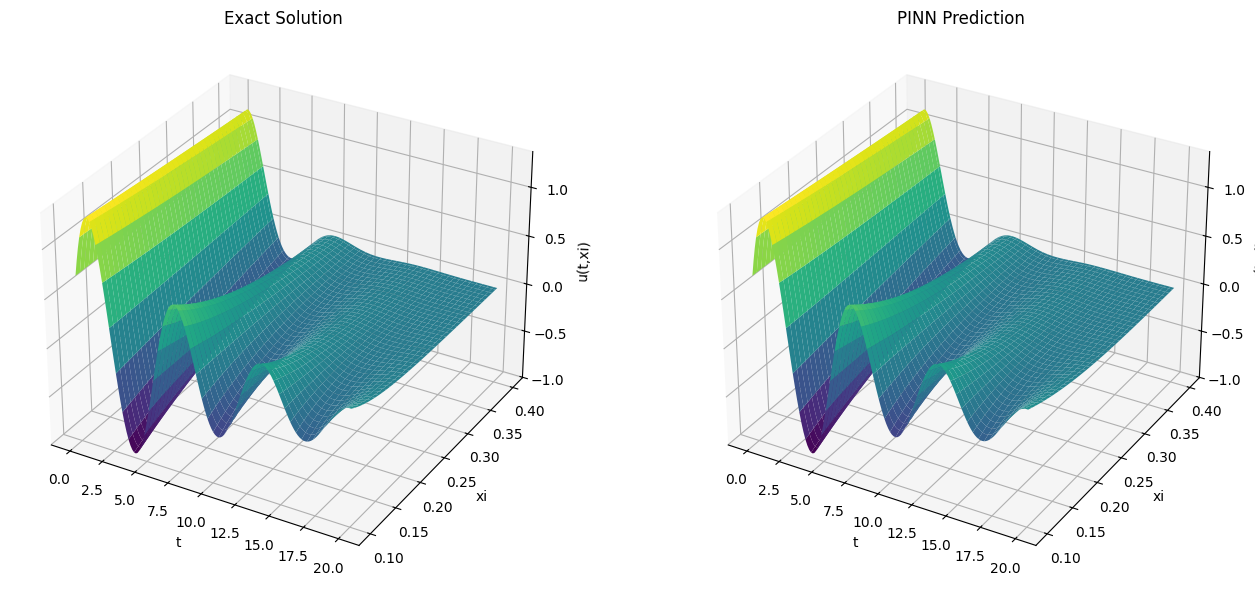

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----- Dense evaluation grid -----
t_axis = torch.linspace(0, T, 150, device=device)
xi_axis = torch.linspace(0.1, 0.4, 80, device=device)

Tg, Xig = torch.meshgrid(t_axis, xi_axis, indexing="ij")
z_test = torch.stack([Tg.reshape(-1), Xig.reshape(-1)], dim=1)

# ----- Evaluate model and exact solution -----
model.eval()
with torch.no_grad():
    x_pred = model(z_test).reshape(150, 80)
    x_true = get_exact_solution_torch(
        z_test[:,0:1], z_test[:,1:2]
    ).reshape(150,80)

Tg = Tg.cpu().numpy()
Xig = Xig.cpu().numpy()
x_pred = x_pred.cpu().numpy()
x_true = x_true.cpu().numpy()

# ----- Plot surfaces -----
fig = plt.figure(figsize=(14,6))

# Exact solution
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(Tg, Xig, x_true, cmap='viridis', linewidth=0)
ax1.set_title("Exact Solution")
ax1.set_xlabel("t")
ax1.set_ylabel("xi")
ax1.set_zlabel("u(t,xi)")

# PINN prediction
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(Tg, Xig, x_pred, cmap='viridis', linewidth=0)
ax2.set_title("PINN Prediction")
ax2.set_xlabel("t")
ax2.set_ylabel("xi")
ax2.set_zlabel("u(t,xi)")

plt.tight_layout()
plt.show()

In [6]:
xi_index = 15  # mid xi slice

plt.figure(figsize=(7,5))
plt.plot(t_axis.cpu(), x_true_grid[:,xi_index], label="Exact")
plt.plot(t_axis.cpu(), x_pred_grid[:,xi_index], '--', label="PINN")
plt.xlabel("t")
plt.ylabel("u(t,xi)")
plt.title(f"Solution slice at xi={xi_axis[xi_index]:.3f}")
plt.legend()
plt.show()

NameError: name 'x_true_grid' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
error = x_true_grid - x_pred_grid

plt.figure(figsize=(6,5))
plt.contourf(Tg.cpu(), Xig.cpu(), error, levels=50, cmap='inferno')
plt.title("Absolute Error |u_true - u_pred|")
plt.xlabel("t")
plt.ylabel("xi")
plt.colorbar()
plt.show()

In [ ]:
rel_error_t = np.linalg.norm(x_true_grid - x_pred_grid, axis=1) / np.linalg.norm(x_true_grid, axis=1)

plt.plot(t_axis.cpu(), rel_error_t)
plt.xlabel("t")
plt.ylabel("Relative L2 Error")
plt.title("Relative Error vs Time")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----- Dense grid for visualization -----
t_axis = torch.linspace(0, T, 150, device=device)
xi_axis = torch.linspace(0.1, 0.4, 80, device=device)

Tg, Xig = torch.meshgrid(t_axis, xi_axis, indexing="ij")
z_test = torch.stack([Tg.reshape(-1), Xig.reshape(-1)], dim=1)

# ----- Evaluate model -----
model.eval()
with torch.no_grad():
    x_pred = model(z_test).reshape(150,80)
    x_true = get_exact_solution_torch(
        z_test[:,0:1], z_test[:,1:2]
    ).reshape(150,80)

# ----- Residual -----
residual = (x_true - x_pred)

# convert to numpy
Tg = Tg.cpu().numpy()
Xig = Xig.cpu().numpy()
residual = residual.cpu().numpy()

# ----- Plot residual surface -----
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Tg,
    Xig,
    residual,
    cmap='coolwarm',
    linewidth=0,
    antialiased=True
)

ax.set_title("Residual Surface (True - Pred)")
ax.set_xlabel("t")
ax.set_ylabel("xi")
ax.set_zlabel("Residual")

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.tight_layout()
plt.show()